# **1. PARAMETERS INITIALIZATION**

In [1]:
import json

def ask_int(prompt, default):
    while True:
        raw = input(f"{prompt} (default {default}): ").strip()
        if raw == "":
            return int(default)
        try:
            return int(float(raw))


        except ValueError:
            print("Please enter a valid integer.")

def ask_float(prompt, default):
    while True:
        raw = input(f"{prompt} (default {default}): ").strip()
        if raw == "":
            return float(default)
        try:
            return float(raw)
        except ValueError:
            print("Please enter a valid number.")

def ask_currency(prompt, default):
    val = ask_float(prompt, default)
    if float(val).is_integer():
        return int(val)
    return val

# ------------------------
# DEFAULT CONFIGURATIONS
# ------------------------
DEFAULTS = {
    "WEEKS": 104,
    "LEAD_TIME": 2,
    "OUL_FACTOR": 3,
    "INITIAL_INVENTORY": 80,
    # Demand distribution default params (normal)
    "DEMAND_PARAMS": {"mean": 25.0, "std": 5.0},

    "PRICING": {
        "retailer": {"sell": 170, "buy": 130},
        "distributor": {"sell": 130, "buy": 100},
        "manufacturer": {"sell": 100, "buy": 60}
    },

    "CREDIT_TERMS": {
        "retailer": {"pay_supplier": 2, "receive_customer": 0},
        "distributor": {"pay_supplier": 2, "receive_customer": 2},
        "manufacturer": {"pay_supplier": 0, "receive_customer": 2}
    },

    "INITIAL_CASH": {
        "retailer": 10000,
        "distributor": 30000,
        "manufacturer": 50000
    },

    "HOLDING_COST": {
        "retailer": 15,
        "distributor": 10,
        "manufacturer": 5
    },

    "SHORTAGE_COST": {
        "retailer": 40,
        "distributor": 30,
        "manufacturer": 40
    }
}

# ------------------------
# Ask user whether to use defaults or change
# ------------------------
print("Do you want to Continue with the Default Parameters or Change?")

while True:
    choice = input("Enter 'y' for Default Parameters OR 'n' to Change: ").strip().lower()
    if choice == "":
        choice = "y"
    if choice in ("y", "n"):
        break
    print("Please enter either 'y' or 'n'.")

# ------------------------
# Build configuration
# ------------------------
if choice == "y":
    config = json.loads(json.dumps(DEFAULTS))
else:
    config = {}
    print("\nYou chose to change parameters.\n")
    config["WEEKS"] = ask_int("Number of weeks", DEFAULTS["WEEKS"])
    #config["LEAD_TIME"] = ask_int("Lead Time (weeks)", DEFAULTS["LEAD_TIME"])
    #config["OUL_FACTOR"] = ask_int("OUL Factor", DEFAULTS["OUL_FACTOR"])
    config["INITIAL_INVENTORY"] = ask_int("Initial Inventory", DEFAULTS["INITIAL_INVENTORY"])

    # Demand: ALWAYS ask mean and std (no choice asked here)
    print("\nDemand distribution will be Normal. Enter distribution parameters:")
    mean_val = ask_float("  Mean (average demand)", DEFAULTS["DEMAND_PARAMS"]["mean"])
    std_val = ask_float("  Standard deviation (std)", DEFAULTS["DEMAND_PARAMS"]["std"])
    if std_val < 0:
        print("  Note: std cannot be negative. Using absolute value.")
        std_val = abs(std_val)
    config["DEMAND_PARAMS"] = {"mean": float(mean_val), "std": float(std_val)}

    # Pricing
    pricing = {}
    for role, vals in DEFAULTS["PRICING"].items():
        print(f"\n--- {role.capitalize()} Pricing ---")
        sell = ask_currency("  Selling Price", vals["sell"])
        buy = ask_currency("  Purchase/Production Cost", vals["buy"])
        pricing[role] = {"sell": sell, "buy": buy}
    config["PRICING"] = pricing

    # Credit terms
    credit = {}
    for role, vals in DEFAULTS["CREDIT_TERMS"].items():
        print(f"\n--- {role.capitalize()} Credit Terms ---")
        pay = ask_int("  Weeks to Pay Supplier", vals["pay_supplier"])
        rec = ask_int("  Weeks to Receive Payment from Customer", vals["receive_customer"])
        credit[role] = {"pay_supplier": pay, "receive_customer": rec}
    config["CREDIT_TERMS"] = credit

    # Initial Cash
    cash = {}
    for role, val in DEFAULTS["INITIAL_CASH"].items():
        cash[role] = ask_currency(f"  Initial Cash ({role.capitalize()})", val)
    config["INITIAL_CASH"] = cash

    # Holding cost
    hold = {}
    for role, val in DEFAULTS["HOLDING_COST"].items():
        hold[role] = ask_currency(f"  Holding Cost ({role.capitalize()})", val)
    config["HOLDING_COST"] = hold

    # Shortage cost
    short = {}
    for role, val in DEFAULTS["SHORTAGE_COST"].items():
        short[role] = ask_currency(f"  Shortage Cost ({role.capitalize()})", val)
    config["SHORTAGE_COST"] = short

# ensure all keys exist
for k in ("WEEKS","LEAD_TIME","INITIAL_INVENTORY","OUL_FACTOR","DEMAND_PARAMS",
          "PRICING","CREDIT_TERMS","INITIAL_CASH","HOLDING_COST","SHORTAGE_COST"):
    if k not in config:
        config[k] = DEFAULTS[k]

# ------------------------
# Print clear parameter table
# ------------------------
def print_table(title, rows):
    print("\n" + title)
    print("-" * len(title))
    col1 = max(len(r[0]) for r in rows) + 2
    col2 = max(len(str(r[1])) for r in rows) + 2
    for key, val in rows:
        print(f"{key.ljust(col1)}{str(val).rjust(col2)}")
    print()

# display demand as NORM.INV(RAND(),mean,std)
mean = config["DEMAND_PARAMS"]["mean"]
std = config["DEMAND_PARAMS"]["std"]
demand_expr = f"NORM.INV(RAND(),{mean},{std})"

print_table("MAIN PARAMETERS", [
    ("Number of weeks", f"1 to {config['WEEKS']}"),
    ("Lead Time", config["LEAD_TIME"]),
    ("OUL Factor", config["OUL_FACTOR"]),
    ("Initial Inventory", config["INITIAL_INVENTORY"]),
    ("Demand Distribution", demand_expr)
])

print_table("PRICING", [
    ("Retailer Selling Price", config["PRICING"]["retailer"]["sell"]),
    ("Retailer Purchase Price", config["PRICING"]["retailer"]["buy"]),
    ("Distributor Selling Price", config["PRICING"]["distributor"]["sell"]),
    ("Distributor Purchase Price", config["PRICING"]["distributor"]["buy"]),
    ("Manufacturer Selling Price", config["PRICING"]["manufacturer"]["sell"]),
    ("Manufacturer Production Cost", config["PRICING"]["manufacturer"]["buy"])
])

print_table("CREDIT TERMS", [
    ("Credit [Customer → Retailer]", config["CREDIT_TERMS"]["retailer"]["receive_customer"]),
    ("Credit [Retailer → Distributor]", config["CREDIT_TERMS"]["retailer"]["pay_supplier"]),
    ("Credit [Distributor → Manufacturer]", config["CREDIT_TERMS"]["distributor"]["pay_supplier"])
])

print_table("INITIAL CASH", [
    ("Initial Cash [Retailer]", config["INITIAL_CASH"]["retailer"]),
    ("Initial Cash [Distributor]", config["INITIAL_CASH"]["distributor"]),
    ("Initial Cash [Manufacturer]", config["INITIAL_CASH"]["manufacturer"])
])

print_table("HOLDING COST PER WEEK PER UNIT", [
    ("Retailer", config["HOLDING_COST"]["retailer"]),
    ("Distributor", config["HOLDING_COST"]["distributor"]),
    ("Manufacturer", config["HOLDING_COST"]["manufacturer"])
])

print_table("SHORTAGE COST PER WEEK PER UNIT", [
    ("Retailer", config["SHORTAGE_COST"]["retailer"]),
    ("Distributor", config["SHORTAGE_COST"]["distributor"]),
    ("Manufacturer", config["SHORTAGE_COST"]["manufacturer"])
])

# ------------------------
# Save config to JSON for Block B

with open("config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)
print("Saved configuration to config.json\n")

Do you want to Continue with the Default Parameters or Change?
Enter 'y' for Default Parameters OR 'n' to Change: y

MAIN PARAMETERS
---------------
Number of weeks                         1 to 104
Lead Time                                      2
OUL Factor                                     3
Initial Inventory                             80
Demand Distribution    NORM.INV(RAND(),25.0,5.0)


PRICING
-------
Retailer Selling Price          170
Retailer Purchase Price         130
Distributor Selling Price       130
Distributor Purchase Price      100
Manufacturer Selling Price      100
Manufacturer Production Cost     60


CREDIT TERMS
------------
Credit [Customer → Retailer]           0
Credit [Retailer → Distributor]        2
Credit [Distributor → Manufacturer]    2


INITIAL CASH
------------
Initial Cash [Retailer]        10000
Initial Cash [Distributor]     30000
Initial Cash [Manufacturer]    50000


HOLDING COST PER WEEK PER UNIT
------------------------------
Retailer        15

# **2. DEMAND INITIALIZATION**

In [2]:
import json
import numpy as np
import sys

# Load configuration (from Block A)
with open("config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Excel (fixed) demand data for 104 weeks (same as your earlier array)
DEFAULT_CUSTOMER_DEMAND = np.array([
    25,24,15,21,26,24,26,9,18,22,23,24,20,24,20,19,17,17,14,27,
    20,12,21,13,24,26,14,18,25,27,20,12,16,23,13,17,15,14,22,22,
    19,10,22,17,31,10,27,27,16,17,16,16,22,24,15,19,14,23,19,19,
    31,13,21,17,20,23,24,17,17,19,21,29,16,23,20,23,24,22,16,23,
    14,20,19,27,26,14,13,32,23,31,24,29,24,22,19,19,25,21,26,15,
    17,32,22,24
], dtype=float)

# ------------------------
# Demand selection
# ------------------------
print("\nDemand Selection")
print("You can choose to use the Default Excel demand (useful for comparisons) or generate randomized demand.")


while True:
    choice = input("Enter 'd' for Default Excel demand OR 'r' for Random Normal demand: ").strip().lower()
    if choice == "":
        choice = "d"
    if choice in ("d", "r"):
        break
    print("Please enter 'd' or 'r'.")

# ------------------------
# Produce CUSTOMER_DEMAND_DATA
# ------------------------
if choice == "d":
    CUSTOMER_DEMAND_DATA = DEFAULT_CUSTOMER_DEMAND.copy().astype(int)
    print("\nUsing Default Excel demand =", CUSTOMER_DEMAND_DATA)

else:
    # Use mean & std and weeks from config saved by Block A — no hard-coded defaults here
    try:
        weeks = int(config["WEEKS"])
    except KeyError:
        raise KeyError("WEEKS not found in config.json. Run Block A first to create config.json with WEEKS.")

    try:
        demand_params = config["DEMAND_PARAMS"]
        mean = float(demand_params["mean"])
        std = float(demand_params["std"])
    except KeyError:
        raise KeyError("DEMAND_PARAMS (mean/std) not found in config.json. Run Block A first to set DEMAND_PARAMS.")

    # reproducible seed; change/remove if you want different draws each run
    np.random.seed(42)
    vals = np.random.normal(loc=mean, scale=std, size=weeks)
    CUSTOMER_DEMAND_DATA = np.maximum(0, np.round(vals)).astype(int)

    print(f"\nGenerated Random Normal demand the below values")
    print(f"  mean = {mean}, std = {std}, weeks = {weeks}")
    print("Sample (first 10):", CUSTOMER_DEMAND_DATA[:10])

# ------------------------
# CUSTOMER_DEMAND_DATA ready
# ------------------------
print("\nReady for simulation....")
# Optional: save to csv
# np.savetxt("customer_demand.csv", CUSTOMER_DEMAND_DATA, delimiter=",", fmt="%d")



Demand Selection
You can choose to use the Default Excel demand (useful for comparisons) or generate randomized demand.
Enter 'd' for Default Excel demand OR 'r' for Random Normal demand: d

Using Default Excel demand = [25 24 15 21 26 24 26  9 18 22 23 24 20 24 20 19 17 17 14 27 20 12 21 13
 24 26 14 18 25 27 20 12 16 23 13 17 15 14 22 22 19 10 22 17 31 10 27 27
 16 17 16 16 22 24 15 19 14 23 19 19 31 13 21 17 20 23 24 17 17 19 21 29
 16 23 20 23 24 22 16 23 14 20 19 27 26 14 13 32 23 31 24 29 24 22 19 19
 25 21 26 15 17 32 22 24]

Ready for simulation....


# **3. RUN THE SIMULATION**

In [3]:
import math
import pandas as pd

def run_simulation(config, customer_demand):

    # -------------------------------
    # 1. Setup Parameters
    # -------------------------------
    WEEKS = config["WEEKS"]
    INITIAL_INVENTORY = config["INITIAL_INVENTORY"]
    OUL_FACTOR = config["OUL_FACTOR"]
    LEAD_TIME = config["LEAD_TIME"]

    PRICING_SIM = {}
    for role in ["retailer", "distributor", "manufacturer"]:
        PRICING_SIM[role] = {
            "sell": config["PRICING"][role]["sell"],
            "buy": config["PRICING"][role]["buy"],
            "holding": config["HOLDING_COST"][role],
            "shortage": config["SHORTAGE_COST"][role],
            "initial_cash": config["INITIAL_CASH"][role]
        }

    CREDIT_TERMS = config["CREDIT_TERMS"]

    # Column names
    COLS = {
        "retailer": {
            "demand": "CUSTOMER DEMAND", "order": "ORDER PLACED TO DISTRIBUTOR",
            "invoice": "INVOICE TO CUSTOMER", "purchase": "PURCHASE COST"
        },
        "distributor": {
            "demand": "ORDERS FROM RETAILER", "order": "ORDER PLACED TO MANUFACTURER",
            "invoice": "INVOICE TO RETAILER", "purchase": "PURCHASE COST"
        },
        "manufacturer": {
            "demand": "ORDERS FROM DISTRIBUTOR", "order": "ORDER PLACED FOR PRODUCTION",
            "invoice": "INVOICE TO DISTRIBUTOR", "purchase": "PRODUCTION COST"
        }
    }

    def excel_round_up(n):
        return math.ceil(n)

    # -------------------------------
    # 2. Initialization
    # -------------------------------

    history_R, history_D, history_M = [], [], []

    state = {
        "retailer": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["retailer"]["initial_cash"]},
        "distributor": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["distributor"]["initial_cash"]},
        "manufacturer": {"inv": INITIAL_INVENTORY, "cash": PRICING_SIM["manufacturer"]["initial_cash"]}
    }

    transit = {
        "R_incoming_goods": {}, "D_incoming_goods": {}, "M_incoming_goods": {},
        "D_incoming_demand": {}, "M_incoming_demand": {}
    }

    # -------------------------------
    # 3. Main Simulation Loop
    # -------------------------------
    for t in range(WEEKS):
        week = t + 1

        # -----------------------------
        # Incoming
        # -----------------------------
        r_goods_rec = transit["R_incoming_goods"].get(week, 0)
        d_goods_rec = transit["D_incoming_goods"].get(week, 0)
        m_goods_rec = transit["M_incoming_goods"].get(week, 0)

        r_demand = customer_demand[t] if t < len(customer_demand) else 0
        d_demand = transit["D_incoming_demand"].get(week, 0)
        m_demand = transit["M_incoming_demand"].get(week, 0)

        # -----------------------------
        # Forecast + OUL + Orders
        # -----------------------------
        def plan(entity, demand, hist, goods_rec):
            cols = COLS[entity]

            if week == 1:
                fc = 20
            elif week == 2:
                fc = hist[0][cols["demand"]]
            else:
                d1 = hist[t-1][cols["demand"]]
                d2 = hist[t-2][cols["demand"]]
                fc = excel_round_up((d1 + d2) / 2)

            oul = OUL_FACTOR * fc
            beg_inv = state[entity]["inv"] + goods_rec

            if t == 0:
                prev_order = 0
            else:
                prev_order = hist[t-1][cols["order"]]

            inv_pos = beg_inv + prev_order
            order = max(0, oul - inv_pos)
            return fc, oul, beg_inv, inv_pos, order

        r_fc, r_oul, r_beg, r_ip, r_order = plan("retailer", r_demand, history_R, r_goods_rec)
        d_fc, d_oul, d_beg, d_ip, d_order = plan("distributor", d_demand, history_D, d_goods_rec)
        m_fc, m_oul, m_beg, m_ip, m_order = plan("manufacturer", m_demand, history_M, m_goods_rec)

        # -----------------------------
        # Fulfillment
        # -----------------------------
        def fulfill(beg, demand):
            sold = min(beg, demand)
            lost = max(0, demand - beg)
            end = beg - sold
            return beg, sold, lost, end

        r_avail, r_sold, r_lost, r_end = fulfill(r_beg, r_demand)
        d_avail, d_sold, d_lost, d_end = fulfill(d_beg, d_demand)
        m_avail, m_sold, m_lost, m_end = fulfill(m_beg, m_demand)

        state["retailer"]["inv"] = r_end
        state["distributor"]["inv"] = d_end
        state["manufacturer"]["inv"] = m_end

        # -----------------------------
        # Delay Scheduling
        # -----------------------------
        transit["D_incoming_demand"][week+1] = r_order
        transit["M_incoming_demand"][week+1] = d_order

        transit["R_incoming_goods"][week+1] = d_sold
        transit["D_incoming_goods"][week+1] = m_sold

        transit["M_incoming_goods"][week+LEAD_TIME] = m_order

        # -----------------------------
        # Financials
        # -----------------------------
        def finance(role, sold, goods_rec, end_inv, lost_sales, hist):
            p = PRICING_SIM[role]
            c = CREDIT_TERMS[role]
            cols = COLS[role]

            invoice = sold * p["sell"]
            purchase = goods_rec * p["buy"]
            hold = end_inv * p["holding"]
            short = lost_sales * p["shortage"]

            # Inflow
            if t >= c["receive_customer"]:
                inflow = invoice if c["receive_customer"] == 0 \
                    else hist[t - c["receive_customer"]][cols["invoice"]]
            else:
                inflow = 0

            # Outflow
            if t >= c["pay_supplier"]:
                outflow = purchase if c["pay_supplier"] == 0 \
                    else hist[t - c["pay_supplier"]][cols["purchase"]]
            else:
                outflow = 0

            net = inflow - outflow - hold - short

            if t == 0:
                state[role]["cash"] = p["initial_cash"]
            else:
                state[role]["cash"] += net

            ap = purchase
            ar = invoice

            return invoice, purchase, hold, short, inflow, outflow, net, state[role]["cash"], ap, ar

        r_fin = finance("retailer", r_sold, r_goods_rec, r_end, r_lost, history_R)
        d_fin = finance("distributor", d_sold, d_goods_rec, d_end, d_lost, history_D)
        m_fin = finance("manufacturer", m_sold, m_goods_rec, m_end, m_lost, history_M)

        # -----------------------------
        # Record History (Loop Append)
        # Note: Inv Weeks and C2C are calculated after the loop
        # -----------------------------

        history_R.append({
            "WEEK": week, COLS['retailer']['demand']: r_demand,
            "FORECAST": r_fc, "OUL": r_oul, "GOODS RECEIVED": r_goods_rec,
            "BEGINNING INVENTORY": r_beg, "INVENTORY POSITION": r_ip,
            "ORDER PLACED TO DISTRIBUTOR": r_order,
            "GOODS AVAILABLE": r_avail, "UNITS SOLD": r_sold,
            "LOST SALES": r_lost, "ENDING INVENTORY": r_end,
            "INVOICE TO CUSTOMER": r_fin[0], "PURCHASE COST": r_fin[1],
            "HOLDING COST": r_fin[2], "SHORTAGE COST": r_fin[3],
            "PAYMENT RECEIVED": r_fin[4], "PAYMENT MADE TO DISTRIBUTOR": r_fin[5],
            "NET CASH FLOW": r_fin[6], "CASH POSITION": r_fin[7],
            "ACCOUNTS PAYABLE": r_fin[8], "ACCOUNTS RECEIVABLE": r_fin[9]
        })

        history_D.append({
            "WEEK": week, COLS['distributor']['demand']: d_demand,
            "FORECAST": d_fc, "OUL": d_oul, "GOODS RECEIVED": d_goods_rec,
            "BEGINNING INVENTORY": d_beg, "INVENTORY POSITION": d_ip,
            "ORDER PLACED TO MANUFACTURER": d_order,
            "GOODS AVAILABLE": d_avail, "UNITS SOLD TO RETAILER": d_sold,
            "LOST SALES": d_lost, "ENDING INVENTORY": d_end,
            "INVOICE TO RETAILER": d_fin[0], "PURCHASE COST": d_fin[1],
            "HOLDING COST": d_fin[2], "SHORTAGE COST": d_fin[3],
            "PAYMENT RECEIVED": d_fin[4], "PAYMENT MADE TO MANUFACTURER": d_fin[5],
            "NET CASH FLOW": d_fin[6], "CASH POSITION": d_fin[7],
            "ACCOUNTS PAYABLE": d_fin[8], "ACCOUNTS RECEIVABLE": d_fin[9]
        })

        history_M.append({
            "WEEK": week, COLS['manufacturer']['demand']: m_demand,
            "FORECAST": m_fc, "OUL": m_oul, "GOODS RECEIVED": m_goods_rec,
            "BEGINNING INVENTORY": m_beg, "INVENTORY POSITION": m_ip,
            "ORDER PLACED FOR PRODUCTION": m_order,
            "GOODS AVAILABLE": m_avail, "UNITS SHIPPED TO DISTRIBUTOR": m_sold,
            "LOST SALES": m_lost, "ENDING INVENTORY": m_end,
            "INVOICE TO DISTRIBUTOR": m_fin[0], "PRODUCTION COST": m_fin[1],
            "HOLDING COST": m_fin[2], "SHORTAGE COST": m_fin[3],
            "PAYMENT RECEIVED": m_fin[4], "PAYMENT MADE": m_fin[5],
            "NET CASH FLOW": m_fin[6], "CASH POSITION": m_fin[7],
            "ACCOUNTS PAYABLE": m_fin[8], "ACCOUNTS RECEIVABLE": m_fin[9]
        })

    # -------------------------------
    # 4. Post-Simulation Calculations
    # (Inventory Weeks & C2C with RoundUp)
    # -------------------------------

    # Convert lists to DataFrames
    retailer_df = pd.DataFrame(history_R)
    distributor_df = pd.DataFrame(history_D)
    manufacturer_df = pd.DataFrame(history_M)

    # Calculate Global Averages
    avg_customer_demand = retailer_df[COLS['retailer']['demand']].mean()
    avg_retailer_orders = retailer_df[COLS['retailer']['order']].mean()
    avg_distributor_orders = distributor_df[COLS['distributor']['order']].mean()

    # --- RETAILER CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_customer_demand > 0:
        raw_ret_inv = retailer_df["ENDING INVENTORY"] / avg_customer_demand
    else:
        raw_ret_inv = retailer_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    ret_c2c_offset = CREDIT_TERMS["retailer"]["receive_customer"] - CREDIT_TERMS["retailer"]["pay_supplier"]
    raw_ret_c2c = raw_ret_inv + ret_c2c_offset

    # 3. Apply Excel Round Up
    retailer_df["INVENTORY WEEKS"] = raw_ret_inv.apply(excel_round_up)
    retailer_df["CASH TO CASH CYCLE TIME"] = raw_ret_c2c.apply(excel_round_up)


    # --- DISTRIBUTOR CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_retailer_orders > 0:
        raw_dist_inv = distributor_df["ENDING INVENTORY"] / avg_retailer_orders
    else:
        raw_dist_inv = distributor_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    dist_c2c_offset = CREDIT_TERMS["distributor"]["receive_customer"] - CREDIT_TERMS["distributor"]["pay_supplier"]
    raw_dist_c2c = raw_dist_inv + dist_c2c_offset

    # 3. Apply Excel Round Up
    distributor_df["INVENTORY WEEKS"] = raw_dist_inv.apply(excel_round_up)
    distributor_df["CASH TO CASH CYCLE TIME"] = raw_dist_c2c.apply(excel_round_up)


    # --- MANUFACTURER CALCULATIONS ---
    # 1. Calc Raw Inventory Weeks
    if avg_distributor_orders > 0:
        raw_manu_inv = manufacturer_df["ENDING INVENTORY"] / avg_distributor_orders
    else:
        raw_manu_inv = manufacturer_df["ENDING INVENTORY"] * 0

    # 2. Calc Raw C2C
    manu_c2c_offset = CREDIT_TERMS["manufacturer"]["receive_customer"] - 0
    raw_manu_c2c = raw_manu_inv + manu_c2c_offset

    # 3. Apply Excel Round Up
    manufacturer_df["INVENTORY WEEKS"] = raw_manu_inv.apply(excel_round_up)
    manufacturer_df["CASH TO CASH CYCLE TIME"] = raw_manu_c2c.apply(excel_round_up)

    return (
        retailer_df,
        distributor_df,
        manufacturer_df,
        COLS
    )

retailer_df, distributor_df, manufacturer_df, COLS = run_simulation(config, CUSTOMER_DEMAND_DATA)

print("\nSimulation Completed Successfully...")


# Save CSV files
retailer_df.to_csv("retailer.csv", index=False)
distributor_df.to_csv("distributor.csv", index=False)
manufacturer_df.to_csv("manufacturer.csv", index=False)

print("\nCheck the Below Code Blocks to see the Results")


Simulation Completed Successfully...

Check the Below Code Blocks to see the Results


# **4. DOWNLOAD THE EXCEL FILES**

In [ ]:
# Download these in Google Colab
from google.colab import files

files.download("retailer.csv")
files.download("distributor.csv")
files.download("manufacturer.csv")
print("Please Allow the DOWNLOAD MULTIPLE FILES option")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Please Allow the DOWNLOAD MULTIPLE FILES option


# **5. VISUALIZE THE RETAILER PERFORMANCE**

In [4]:
import json
with open("config.json", "r") as f:
    config = json.load(f)
weeks = config["WEEKS"]

print(f"Total Number of Weeks: {weeks}")
X = int(input("Performance of Retailer starting from the week:"))
Y = int(input("Performance of Retailer ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- RETAILER PREVIEW ---")
display(retailer_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Retailer starting from the week:21
Performance of Retailer ending to the week:25


--- RETAILER PREVIEW ---


,WEEK,CUSTOMER DEMAND,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED TO DISTRIBUTOR,GOODS AVAILABLE,UNITS SOLD,LOST SALES,ENDING INVENTORY,INVOICE TO CUSTOMER,PURCHASE COST,HOLDING COST,SHORTAGE COST,PAYMENT RECEIVED,PAYMENT MADE TO DISTRIBUTOR,NET CASH FLOW,CASH POSITION,ACCOUNTS PAYABLE,ACCOUNTS RECEIVABLE,INVENTORY WEEKS,CASH TO CASH CYCLE TIME
20,21,20,21,63,14,14,25,38,14,14,6,0,2380,1820,0,240,2380,1690,450,26385,1820,2380,0,-2
21,22,12,24,72,11,11,49,23,11,11,1,0,1870,1430,0,40,1870,1430,400,26785,1430,1870,0,-2
22,23,21,16,48,38,38,61,0,38,21,0,17,3570,4940,255,0,3570,1820,1495,28280,4940,3570,1,-1
23,24,13,17,51,12,29,29,22,29,13,0,16,2210,1560,240,0,2210,1430,540,28820,1560,2210,1,-1
24,25,24,17,51,0,16,38,13,16,16,8,0,2720,0,0,320,2720,4940,-2540,26280,0,2720,0,-2


# **6. VISUALIZE THE DISTRIBUTOR PERFORMANCE**

In [5]:
import json
with open("config.json", "r") as f:
    config = json.load(f)
weeks = config["WEEKS"]

print(f"Total Number of Weeks: {weeks}")
X = int(input("Performance of Distributor starting from the week:"))
Y = int(input("Performance of Distributor ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- DISTRIBUTOR PREVIEW ---")
display(distributor_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Distributor starting from the week:21
Performance of Distributor ending to the week:25


--- DISTRIBUTOR PREVIEW ---


,WEEK,ORDERS FROM RETAILER,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED TO MANUFACTURER,GOODS AVAILABLE,UNITS SOLD TO RETAILER,LOST SALES,ENDING INVENTORY,INVOICE TO RETAILER,PURCHASE COST,HOLDING COST,SHORTAGE COST,PAYMENT RECEIVED,PAYMENT MADE TO MANUFACTURER,NET CASH FLOW,CASH POSITION,ACCOUNTS PAYABLE,ACCOUNTS RECEIVABLE,INVENTORY WEEKS,CASH TO CASH CYCLE TIME
20,21,11,13,39,0,61,61,0,61,11,0,50,1430,0,500,0,1430,5900,-4970,29450,0,1430,3,3
21,22,38,13,39,0,50,50,0,50,38,0,12,4940,0,120,0,1820,0,1700,31150,0,4940,1,1
22,23,23,25,75,0,12,12,63,12,12,11,0,1560,0,0,330,1430,0,1100,32250,0,1560,0,0
23,24,0,31,93,0,0,63,30,0,0,0,0,0,0,0,0,4940,0,4940,37190,0,0,0,0
24,25,22,12,36,63,63,93,0,63,22,0,41,2860,6300,410,0,1560,0,1150,38340,6300,2860,3,3


# **7. VISUALIZE THE MANUFACTURER PERFORMANCE**

In [7]:
import json
with open("config.json", "r") as f:
    config = json.load(f)
weeks = config["WEEKS"]

print(f"Total Number of Weeks: {weeks}")
X = int(input("Performance of Manufacturer starting from the week:"))
Y = int(input("Performance of Manufacturer ending to the week:"))

import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 0)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

print("\n\n--- MANUFACTURER PREVIEW ---")
display(manufacturer_df.iloc[X-1:Y])

Total Number of Weeks: 104
Performance of Manufacturer starting from the week:21
Performance of Manufacturer ending to the week:25


--- MANUFACTURER PREVIEW ---


,WEEK,ORDERS FROM DISTRIBUTOR,FORECAST,OUL,GOODS RECEIVED,BEGINNING INVENTORY,INVENTORY POSITION,ORDER PLACED FOR PRODUCTION,GOODS AVAILABLE,UNITS SHIPPED TO DISTRIBUTOR,LOST SALES,ENDING INVENTORY,INVOICE TO DISTRIBUTOR,PRODUCTION COST,HOLDING COST,SHORTAGE COST,PAYMENT RECEIVED,PAYMENT MADE,NET CASH FLOW,CASH POSITION,ACCOUNTS PAYABLE,ACCOUNTS RECEIVABLE,INVENTORY WEEKS,CASH TO CASH CYCLE TIME
20,21,0,0,0,63,117,117,0,117,0,0,117,0,3780,585,0,0,3780,-4365,49645,3780,0,8,10
21,22,0,0,0,0,117,117,0,117,0,0,117,0,0,585,0,0,0,-585,49060,0,0,8,10
22,23,0,0,0,0,117,117,0,117,0,0,117,0,0,585,0,0,0,-585,48475,0,0,8,10
23,24,63,0,0,0,117,117,0,117,63,0,54,6300,0,270,0,0,0,-270,48205,0,6300,4,6
24,25,30,32,96,0,54,54,42,54,30,0,24,3000,0,120,0,0,0,-120,48085,0,3000,2,4


# **8. PERFORMANCE SUMMARY**

In [8]:
# ==========================================
# BLOCK 4: REPORT GENERATION (Corrected)
# ==========================================
import json
with open("config.json", "r") as f:
    config = json.load(f)
weeks = config["WEEKS"]

print(f"Total Number of Weeks: {weeks}")

# 1. Get User Input
try:
    # Using input() directly. In Colab, this will prompt you.
    start_week_input = input("Performance Summary starting from the week (default 21): ").strip()
    start_week = int(start_week_input) if start_week_input else 21

    end_week_input = input("Performance Summary ending to the week (default 80): ").strip()
    end_week = int(end_week_input) if end_week_input else 80
except ValueError:
    print("Invalid input. Using defaults 21-80.")
    start_week, end_week = 21, 80

# 2. Define Reporting Function
def generate_report(retailer_df, distributor_df, manufacturer_df, COLS, config, start_week, end_week):
    import math
    import pandas as pd

    print("\nGenerating Performance Report...")

    # 0-based index conversion:
    # Week X corresponds to index X-1.
    # Week Y corresponds to index Y-1.
    # Slicing in Python is [start, stop), so [X-1, Y]. This includes index Y-1 (Week Y).

    start_idx = start_week - 1
    end_idx = end_week

    print(f"Analyzing data from Week {start_week} to Week {end_week}...")

    def calculate_metrics(df, role_name, role_cols):
        # Apply the slice for the selected window
        subset = df.iloc[start_idx:end_idx]

        # --- Metric Calculation Logic ---
        total_demand = subset[role_cols['demand']].sum()

        sales_col = "UNITS SOLD" if role_name == "RETAILER" else ("UNITS SOLD TO RETAILER" if role_name == "DISTRIBUTOR" else "UNITS SHIPPED TO DISTRIBUTOR")
        total_sales = subset[sales_col].sum()
        lost_sales = subset["LOST SALES"].sum()

        fill_rate = (1 - (lost_sales / total_demand)) if total_demand > 0 else 0

        avg_inv = subset["ENDING INVENTORY"].mean()
        inv_turnover = total_sales / avg_inv if avg_inv > 0 else 0

        avg_demand = subset[role_cols['demand']].mean()
        inv_duration = math.ceil(avg_inv / avg_demand) if avg_demand > 0 else 0

        total_rev = subset[role_cols['invoice']].sum()
        total_purch = subset[role_cols['purchase']].sum()
        total_hold = subset["HOLDING COST"].sum()
        total_short = subset["SHORTAGE COST"].sum()

        total_op_cost = total_purch + total_hold + total_short
        total_profit = total_rev - total_op_cost
        net_cash_flow = subset["NET CASH FLOW"].sum()
        min_cash = subset["CASH POSITION"].min()
        neg_cash_weeks = (subset["NET CASH FLOW"] < 0).sum()

        role_key = role_name.lower()
        ar_dur = config["CREDIT_TERMS"][role_key]['receive_customer']
        ap_dur = config["CREDIT_TERMS"][role_key]['pay_supplier']

        c2c = inv_duration + ar_dur - ap_dur

        return [
            total_demand, total_sales, lost_sales, fill_rate, avg_inv, inv_turnover, inv_duration,
            total_hold, total_short, total_purch, total_op_cost, total_rev, total_profit,
            net_cash_flow, min_cash, neg_cash_weeks, ar_dur, ap_dur, c2c
        ]

    metric_names = [
        "TOTAL DEMAND", "TOTAL UNITS SOLD", "LOST SALES", "FILL RATE",
        "AVERAGE INVENTORY", "INVENTORY TURNOVER", "INVENTORY DURATION",
        "TOTAL HOLDING COST", "TOTAL SHORTAGE COST", "TOTAL PURCHASE/PRODUCTION COST",
        "TOTAL OPERATIONAL COST", "TOTAL REVENUE", "TOTAL PROFIT",
        "NET CASH FLOW", "MINIMUM CASH POSITION", "NUMBER OF WEEKS WITH NEGATIVE CASH",
        "ACCOUNTS RECEIVABLE DURATION", "ACCOUNTS PAYABLE DURATION", "CASH TO CASH CYCLE TIME"
    ]

    results = {"METRIC": metric_names}

    # Use the DataFrames passed as arguments
    results["MANUFACTURER"] = calculate_metrics(manufacturer_df, "MANUFACTURER", COLS['manufacturer'])
    results["DISTRIBUTOR"] = calculate_metrics(distributor_df, "DISTRIBUTOR", COLS['distributor'])
    results["RETAILER"] = calculate_metrics(retailer_df, "RETAILER", COLS['retailer'])

    final_table = pd.DataFrame(results)

    # Save
    retailer_df.to_csv("retailer.csv", index=False)
    distributor_df.to_csv("distributor.csv", index=False)
    manufacturer_df.to_csv("manufacturer.csv", index=False)
    final_table.to_csv("performance summary.csv", index=False)

    pd.set_option('display.float_format', lambda x: '%.2f' % x)
    print(f"\n--- Traditional Supply Chain Performance Summary (Weeks {start_week}-{end_week}) ---")
    print(final_table.to_string(index=False))
    print("\nFiles saved: performance_summary.csv")

# 3. EXECUTE REPORT GENERATION
# Check for the specific variable names generated in Block 3
if 'retailer_df' in locals() and 'distributor_df' in locals() and 'manufacturer_df' in locals():
    # Pass the correct global variables
    generate_report(retailer_df, distributor_df, manufacturer_df, COLS, config, start_week, end_week)
else:
    print("Error: Simulation data (retailer_df, etc.) not found. Please run the simulation (Block C) first.")

Total Number of Weeks: 104
Performance Summary starting from the week (default 21): 
Performance Summary ending to the week (default 80): 

Generating Performance Report...
Analyzing data from Week 21 to Week 80...

--- Traditional Supply Chain Performance Summary (Weeks 21-80) ---
                            METRIC  MANUFACTURER  DISTRIBUTOR  RETAILER
                      TOTAL DEMAND        990.00      1076.00   1176.00
                  TOTAL UNITS SOLD        964.00       975.00    970.00
                        LOST SALES         26.00       101.00    206.00
                         FILL RATE          0.97         0.91      0.82
                 AVERAGE INVENTORY         73.52        25.13      8.28
                INVENTORY TURNOVER         13.11        38.79    117.10
                INVENTORY DURATION          5.00         2.00      1.00
                TOTAL HOLDING COST      22055.00     15080.00   7455.00
               TOTAL SHORTAGE COST       1040.00      3030.00   8240.

# **9. NUMBER OF ORDERS VS WEEKS**

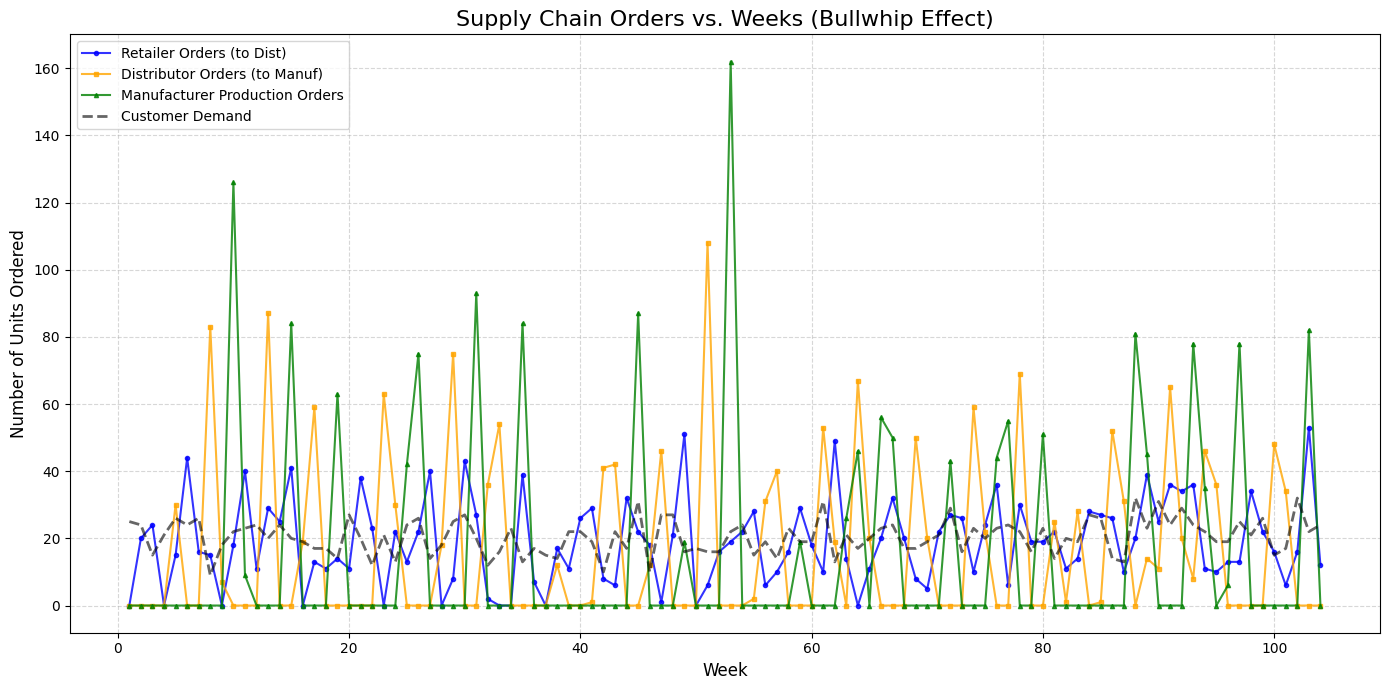

In [9]:
# ==========================================
# GRAPH 1: NUMBER OF ORDERS VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Retailer places orders to Distributor
plt.plot(retailer_df["WEEK"], retailer_df[COLS['retailer']['order']],
         label="Retailer Orders (to Dist)", color='blue', marker='o', markersize=3, linewidth=1.5, alpha=0.8)

# Distributor places orders to Manufacturer
plt.plot(distributor_df["WEEK"], distributor_df[COLS['distributor']['order']],
         label="Distributor Orders (to Manuf)", color='orange', marker='s', markersize=3, linewidth=1.5, alpha=0.8)

# Manufacturer places orders for Production
plt.plot(manufacturer_df["WEEK"], manufacturer_df[COLS['manufacturer']['order']],
         label="Manufacturer Production Orders", color='green', marker='^', markersize=3, linewidth=1.5, alpha=0.8)

# Customer Demand (Reference)
plt.plot(retailer_df["WEEK"], retailer_df[COLS['retailer']['demand']],
         label="Customer Demand", color='black', linestyle='--', linewidth=2, alpha=0.6)

plt.title("Supply Chain Orders vs. Weeks (Bullwhip Effect)", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Number of Units Ordered", fontsize=12)
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_orders_vs_weeks.png")
plt.show()

# **10. CASH POSITION VS WEEKS**

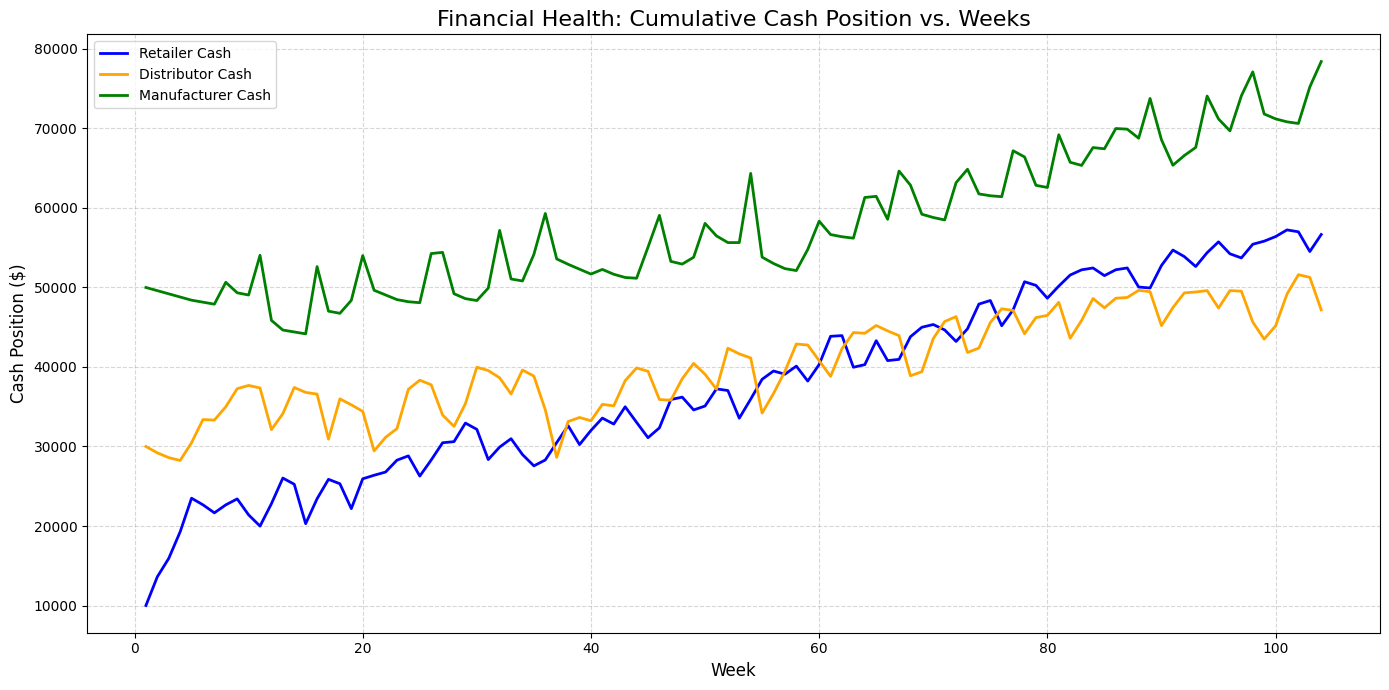

In [10]:
# ==========================================
# GRAPH 2: CASH POSITION VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Cash Positions
plt.plot(retailer_df["WEEK"], retailer_df["CASH POSITION"],
         label="Retailer Cash", color='blue', linewidth=2)

plt.plot(distributor_df["WEEK"], distributor_df["CASH POSITION"],
         label="Distributor Cash", color='orange', linewidth=2)

plt.plot(manufacturer_df["WEEK"], manufacturer_df["CASH POSITION"],
         label="Manufacturer Cash", color='green', linewidth=2)

plt.title("Financial Health: Cumulative Cash Position vs. Weeks", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Cash Position ($)", fontsize=12)
plt.legend(fontsize=10, loc="upper left")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_cash_position.png")
plt.show()

# **11. INVENTORY LEVELS VS WEEKS**

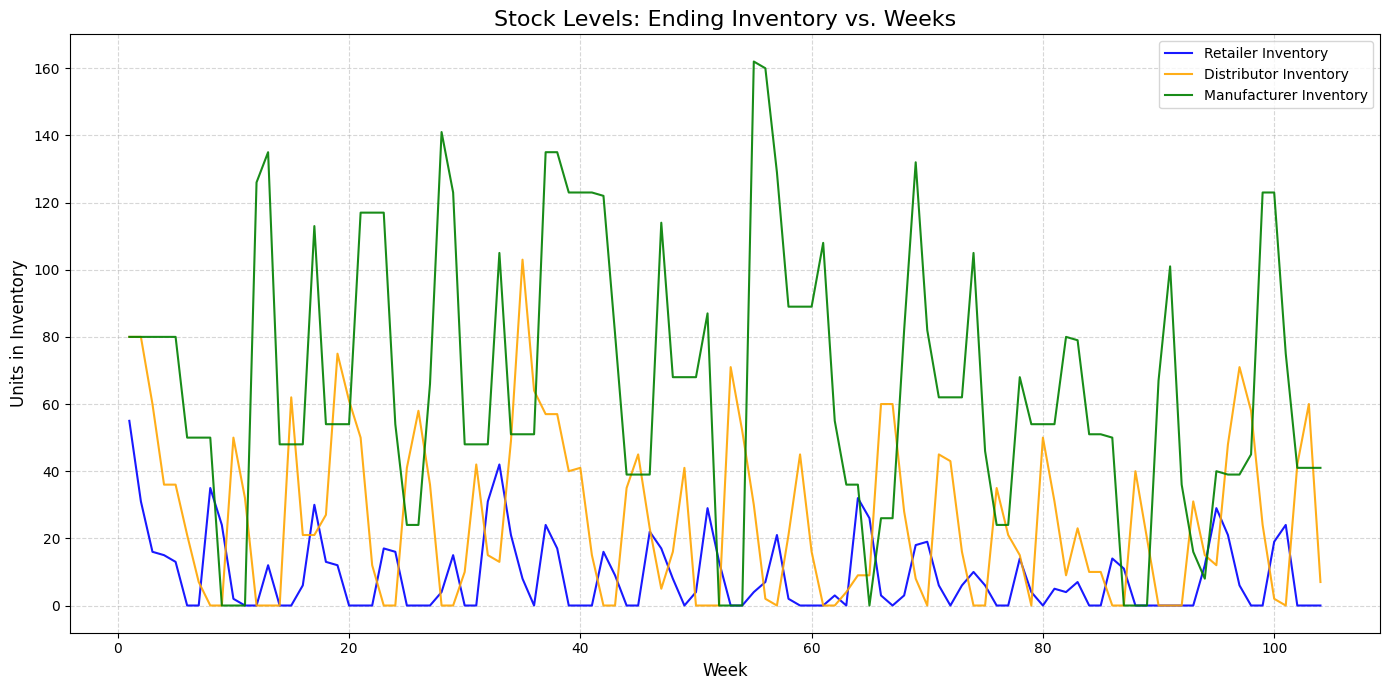

In [ ]:
# ==========================================
# GRAPH 3: INVENTORY LEVELS VS WEEKS
# ==========================================
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Plot Inventory Levels
plt.plot(retailer_df["WEEK"], retailer_df["ENDING INVENTORY"],
         label="Retailer Inventory", color='blue', linewidth=1.5, alpha=0.9)

plt.plot(distributor_df["WEEK"], distributor_df["ENDING INVENTORY"],
         label="Distributor Inventory", color='orange', linewidth=1.5, alpha=0.9)

plt.plot(manufacturer_df["WEEK"], manufacturer_df["ENDING INVENTORY"],
         label="Manufacturer Inventory", color='green', linewidth=1.5, alpha=0.9)

plt.title("Stock Levels: Ending Inventory vs. Weeks", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Units in Inventory", fontsize=12)
plt.legend(fontsize=10, loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and Show
plt.savefig("graph_inventory_levels.png")
plt.show()
